In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests


In [ ]:
import os

# Создаем папку для обработанных данных
os.makedirs("data/processed", exist_ok=True)

# Сохраняем абсолютную численность
df_long_total.to_csv("data/processed/medical_staff_total.csv", index=False)

# Сохраняем численность на 10 000 населения
df_long_per_10k.to_csv("data/processed/medical_staff_per_10k.csv", index=False)

# Сохраняем исходный DataFrame с исходными колонками
df.to_csv("data/processed/medical_staff_cleaned.csv", index=False)

In [4]:
# --- Чтение Excel ---
df = pd.read_excel('/Users/sabina/mosstat_dashboard/data/raw/medical_staff.xlsx', skiprows=2)
df

,Годы,Численность врачей,Unnamed: 2,Численность среднего медицинского персонала,Unnamed: 4
0,NaN,"всего, человек",на 10 000 человек населения1),"всего, человек",на 10 000 человек населения1)
1,2020,88504,68.2,114298,88.1
2,2021,92165,70.8,112457,86.4
3,2022,93964,71.7,113315,86.5
4,2023,98955,75.3,115921,88.2
5,2024,91760,69.1,107850,81.2
6,NaN,NaN,NaN,NaN,NaN
7,1) В расчете на численность постоянного населе...,NaN,NaN,NaN,NaN


In [5]:
# --- Убираем пустые строки (NaN везде) ---
df = df.dropna(how='all')
df

,Годы,Численность врачей,Unnamed: 2,Численность среднего медицинского персонала,Unnamed: 4
0,NaN,"всего, человек",на 10 000 человек населения1),"всего, человек",на 10 000 человек населения1)
1,2020,88504,68.2,114298,88.1
2,2021,92165,70.8,112457,86.4
3,2022,93964,71.7,113315,86.5
4,2023,98955,75.3,115921,88.2
5,2024,91760,69.1,107850,81.2
7,1) В расчете на численность постоянного населе...,NaN,NaN,NaN,NaN


In [6]:
df = df.iloc[1:-1].copy()
df

,Годы,Численность врачей,Unnamed: 2,Численность среднего медицинского персонала,Unnamed: 4
1,2020,88504,68.2,114298,88.1
2,2021,92165,70.8,112457,86.4
3,2022,93964,71.7,113315,86.5
4,2023,98955,75.3,115921,88.2
5,2024,91760,69.1,107850,81.2


In [7]:
# --- Переименовываем колонки ---
df = df.rename(columns={
    "Unnamed: 2": "Численность врачей на 10 000 человек населения",
    "Unnamed: 4": "Численность среднего медицинского персонала на 10 000 человек населения"
})
df

,Годы,Численность врачей,Численность врачей на 10 000 человек населения,Численность среднего медицинского персонала,Численность среднего медицинского персонала на 10 000 человек населения
1,2020,88504,68.2,114298,88.1
2,2021,92165,70.8,112457,86.4
3,2022,93964,71.7,113315,86.5
4,2023,98955,75.3,115921,88.2
5,2024,91760,69.1,107850,81.2


In [8]:
# --- Проверяем текущие имена колонок ---
print(df.columns.tolist())

# --- Убираем лишние пробелы в названиях колонок ---
df.columns = df.columns.str.strip()

# --- Проверяем снова ---
print(df.columns.tolist())

['Годы', 'Численность врачей ', 'Численность врачей на 10 000 человек населения', 'Численность среднего медицинского персонала', 'Численность среднего медицинского персонала на 10 000 человек населения']
['Годы', 'Численность врачей', 'Численность врачей на 10 000 человек населения', 'Численность среднего медицинского персонала', 'Численность среднего медицинского персонала на 10 000 человек населения']


In [9]:
# --- Преобразование в длинный формат для абсолютной численности ---
df_long_total = df.melt(
    id_vars=["Годы"],
    value_vars=["Численность врачей", "Численность среднего медицинского персонала"],
    var_name="staff_type",
    value_name="count"
)

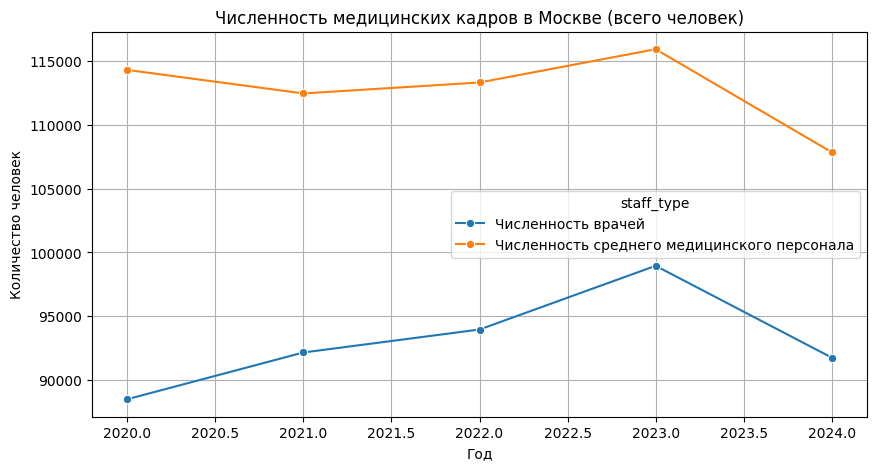

In [10]:
# --- График абсолютной численности ---
plt.figure(figsize=(10,5))
sns.lineplot(data=df_long_total, x="Годы", y="count", hue="staff_type", marker='o')
plt.title("Численность медицинских кадров в Москве (всего человек)")
plt.xlabel("Год")
plt.ylabel("Количество человек")
plt.grid(True)

In [11]:
# --- Преобразование в длинный формат для численности на 10 000 человек населения ---
df_long_per10k = df.melt(
    id_vars=["Годы"],
    value_vars=["Численность врачей на 10 000 человек населения", "Численность среднего медицинского персонала на 10 000 человек населения"],
    var_name="staff_type",
    value_name="count"
)


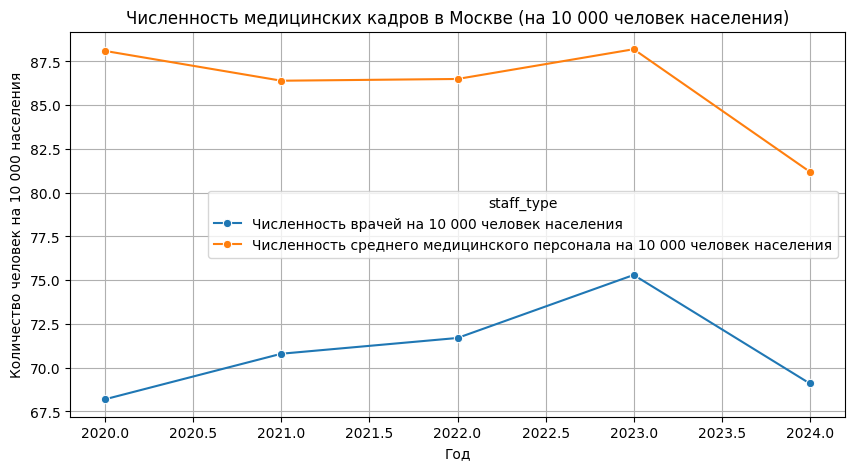

In [12]:
# --- График на 10 000 человек населения ---
plt.figure(figsize=(10,5))
sns.lineplot(data=df_long_per10k, x="Годы", y="count", hue="staff_type", marker='o')
plt.title("Численность медицинских кадров в Москве (на 10 000 человек населения)")
plt.xlabel("Год")
plt.ylabel("Количество человек на 10 000 населения")
plt.grid(True)
plt.show()

In [13]:
# --- Годовой прирост ---
df_growth = df[['Годы', 'Численность врачей', 'Численность среднего медицинского персонала']].copy()
df_growth['Врачи_рост_%'] = df_growth['Численность врачей'].pct_change() * 100
df_growth['СМП_рост_%'] = df_growth['Численность среднего медицинского персонала'].pct_change() * 100

print(df_growth)

   Годы Численность врачей Численность среднего медицинского персонала  \
1  2020              88504                                      114298   
2  2021              92165                                      112457   
3  2022              93964                                      113315   
4  2023              98955                                      115921   
5  2024              91760                                      107850   

  Врачи_рост_% СМП_рост_%  
1          NaN        NaN  
2     4.136536  -1.610702  
3     1.951934   0.762958  
4     5.311609   2.299784  
5    -7.270982    -6.9625  


Численность врачей и среднего медицинского персонала в Москве росла с 2020 по 2023 год, обеспеченность на 10 000 человек населения достигла пика в 2023, затем снизилась в 2024. Доля врачей в общем составе медицинских кадров постепенно увеличивалась до 2023 года. Снижение численности в 2024 может быть связано с перераспределением штатов или корректировками после пандемии. В целом, наблюдается тенденция к стабильному увеличению врачебного состава в последние годы.